In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from glob import glob
from os.path import join
from scipy.ndimage import convolve
from skimage import exposure, img_as_float
from skimage.exposure import equalize_hist
from skimage.feature import hog, local_binary_pattern
from skimage.filters import frangi, gabor, scharr
from skimage.io import imread
from skimage.measure import regionprops
from skimage.morphology import remove_small_objects
from skimage.restoration import denoise_bilateral
from skimage.segmentation import watershed
from skimage.transform import resize
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.multiclass import OneVsRestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import LabelBinarizer, LabelEncoder, StandardScaler
from sklearn.svm import SVC


In [ ]:
# 1. Set the dataset path
DATASET_PATH = r'/content/drive/MyDrive/FYP/20151211-utwente-vingervein/dataset/data/*'

def get_image_path(finger_type='li'):
    mapping = {'li': '0???_1_*.png', 'lm': '0???_2_*.png', 'lr': '0???_3_*.png'}
    sample_pattern = mapping.get(finger_type, '0???_1_*.png')
    folders = sorted(glob(DATASET_PATH))
    path_list = []
    for folder in folders:
        files = sorted(glob(join(folder, sample_pattern)))
        if files:
            path_list.append(pd.Series(files))
    df = pd.DataFrame(path_list)
    df.index.name = 'users'
    df = df.stack()
    df.index.names = ['users', 'samples']
    return df


In [ ]:
# 2. Preprocessing
def fv_preprocess(image):
    image = img_as_float(image)

    # Watershed segmentation
    elevation_map = scharr(image)
    markers = np.zeros_like(image, dtype=np.int32)
    markers[0, :] = 1
    markers[-1, :] = 1
    markers[markers.shape[0] // 2, :] = 2
    segmentation = watershed(elevation_map, markers)
    segmentation2 = (segmentation == 2)
    segmentation2 = remove_small_objects(segmentation2, 100)

    # Histogram equalization
    enhanced_image = equalize_hist(image, mask=segmentation2)

    # Extract ROI and resize
    regions = regionprops(segmentation2.astype(int), intensity_image=enhanced_image)
    enhanced_image = enhanced_image * segmentation2

    if not regions:
        return resize(enhanced_image, (120, 320)), segmentation2, enhanced_image

    roi_image = regions[0].intensity_image
    final_roi = resize(roi_image, (120, 320))

    return final_roi, segmentation2, enhanced_image


In [ ]:
def _to_uint8(image):
    image = np.asarray(image)
    if image.dtype == np.uint8:
        return image
    image = exposure.rescale_intensity(image, out_range=(0, 255))
    return image.astype(np.uint8)


def _l2_normalize(feature):
    feature = np.asarray(feature, dtype=np.float32)
    return feature / (np.linalg.norm(feature) + 1e-7)


def extract_lbp_features(roi_image, P=8, R=2):
    roi_uint8 = _to_uint8(roi_image)
    lbp = local_binary_pattern(roi_uint8, P=P, R=R, method="uniform")
    hist, _ = np.histogram(lbp.ravel(), bins=np.arange(0, P + 3), range=(0, P + 2))
    return _l2_normalize(hist), lbp


def extract_spatial_lbp_features(roi_image, grid=(4, 8), P=8, R=2):
    roi_uint8 = _to_uint8(roi_image)
    lbp = local_binary_pattern(roi_uint8, P=P, R=R, method="uniform")
    h, w = lbp.shape
    gh, gw = grid
    features = []

    for row in range(gh):
        for col in range(gw):
            block = lbp[row * h // gh:(row + 1) * h // gh, col * w // gw:(col + 1) * w // gw]
            hist, _ = np.histogram(block.ravel(), bins=np.arange(0, P + 3), range=(0, P + 2))
            hist = hist.astype(np.float32)
            hist /= hist.sum() + 1e-7
            features.extend(hist)

    return _l2_normalize(features)


def extract_hog_features(roi_image):
    return _l2_normalize(
        hog(
            roi_image,
            orientations=12,
            pixels_per_cell=(12, 12),
            cells_per_block=(2, 2),
            block_norm="L2-Hys",
            transform_sqrt=True,
            feature_vector=True,
        )
    )


def extract_ldp_features(roi_image, top_k=3):
    img_float = roi_image.astype(np.float32)
    if img_float.max() > 1.0:
        img_float /= 255.0

    kirsch_masks = np.array([
        [[-3, -3,  5], [-3, 0,  5], [-3, -3,  5]],
        [[-3,  5,  5], [-3, 0,  5], [-3, -3, -3]],
        [[ 5,  5,  5], [-3, 0, -3], [-3, -3, -3]],
        [[ 5,  5, -3], [ 5, 0, -3], [-3, -3, -3]],
        [[ 5, -3, -3], [ 5, 0, -3], [ 5, -3, -3]],
        [[-3, -3, -3], [ 5, 0, -3], [ 5,  5, -3]],
        [[-3, -3, -3], [-3, 0, -3], [ 5,  5,  5]],
        [[-3, -3, -3], [-3, 0,  5], [-3,  5,  5]],
    ], dtype=np.float32)

    responses = np.stack([convolve(img_float, mask, mode="constant", cval=0.0) for mask in kirsch_masks], axis=-1)
    strongest_dirs = np.argpartition(responses, -top_k, axis=-1)[..., -top_k:]

    ldp = np.zeros(roi_image.shape, dtype=np.uint8)
    for direction in range(8):
        ldp[np.any(strongest_dirs == direction, axis=-1)] |= (1 << direction)

    hist, _ = np.histogram(ldp.ravel(), bins=np.arange(0, 257), range=(0, 256))
    return _l2_normalize(hist), ldp


In [ ]:
def fv_preprocess_v2(image):
    image = img_as_float(image)

    # Denoise while preserving vein edges.
    image = denoise_bilateral(image, sigma_color=0.05, sigma_spatial=3)

    # CLAHE usually works better than global histogram equalization for finger-vein contrast.
    enhanced = exposure.equalize_adapthist(image, clip_limit=0.03)

    # Enhance dark, line-like vein structures.
    vein = frangi(enhanced)
    vein = exposure.rescale_intensity(vein, out_range=(0, 1))

    return resize(vein, (120, 320))


In [ ]:
# 4. Visualization
def save_report_figures(original, seg, enhanced, roi, lbp, ldp=None):
    cols = 6 if ldp is not None else 5
    fig, axes = plt.subplots(1, cols, figsize=(4 * cols, 5))
    axes[0].imshow(original, cmap='gray'); axes[0].set_title("Original Image")
    axes[1].imshow(seg, cmap='gray'); axes[1].set_title("Segmentation Mask")
    axes[2].imshow(enhanced, cmap='gray'); axes[2].set_title("Enhanced Image")
    axes[3].imshow(roi, cmap='gray'); axes[3].set_title("Final ROI (Resized)")
    axes[4].imshow(lbp, cmap='magma'); axes[4].set_title("LBP Texture Map")
    if ldp is not None:
        axes[5].imshow(ldp, cmap='magma'); axes[5].set_title("LDP Texture Map")
    for ax in axes:
        ax.axis('off')
    plt.tight_layout()
    plt.savefig('FYP_Results.png')
    plt.show()


In [ ]:
# 5. Main experiment
# Compares HOG, Gabor + LBP, and HOG + Gabor + LBP handcrafted features.
# Also trains a CNN directly on the enhanced ROI images.


In [ ]:
def build_cnn_model(input_shape, num_classes):
    import tensorflow as tf
    from tensorflow.keras import layers, regularizers

    inputs = tf.keras.Input(shape=input_shape)
    x = layers.RandomFlip("horizontal")(inputs)
    x = layers.RandomRotation(0.03)(x)
    x = layers.RandomZoom(0.05)(x)

    for filters in (32, 64, 128):
        x = layers.Conv2D(filters, 3, padding="same", use_bias=False,
                          kernel_regularizer=regularizers.l2(1e-4))(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)
        x = layers.Conv2D(filters, 3, padding="same", use_bias=False,
                          kernel_regularizer=regularizers.l2(1e-4))(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)
        x = layers.MaxPooling2D()(x)
        x = layers.Dropout(0.25)(x)

    x = layers.Conv2D(256, 3, padding="same", use_bias=False,
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.45)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = tf.keras.Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


def train_evaluate_cnn(images, labels, epochs=80, batch_size=16):
    import tensorflow as tf
    from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

    X = np.asarray(images, dtype=np.float32)
    X = exposure.rescale_intensity(X, out_range=(0, 1)).astype(np.float32)
    X = X[..., np.newaxis]

    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(labels)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y_encoded, test_size=0.20, stratify=y_encoded, random_state=42
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.20, stratify=y_train, random_state=42
    )

    model = build_cnn_model(X_train.shape[1:], len(label_encoder.classes_))
    callbacks = [
        EarlyStopping(monitor="val_accuracy", patience=15, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=6, min_lr=1e-6),
        ModelCheckpoint("best_fingervein_cnn.keras", monitor="val_accuracy", save_best_only=True),
    ]

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=1,
    )

    test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
    probs = model.predict(X_test, verbose=0)
    y_pred = np.argmax(probs, axis=1)

    lb = LabelBinarizer()
    y_test_bin = lb.fit_transform(y_test)
    if y_test_bin.shape[1] == 1:
        y_test_bin = np.hstack([1 - y_test_bin, y_test_bin])
    far_inter_class, frr_intra_class, eer, threshold = _far_frr_eer_from_scores(y_test_bin, probs)

    print(f"CNN Test Accuracy: {test_accuracy:.2%}")
    print(f"CNN Accuracy (1 - EER): {1 - eer:.2%}")
    print(classification_report(y_test, y_pred, target_names=[str(c) for c in label_encoder.classes_]))

    return {
        "Model Type": "CNN",
        "Feature Method": "ROI pixels",
        "Classifier": "CNN",
        "Classification Accuracy": test_accuracy,
        "FAR - Inter class": far_inter_class,
        "FRR - Intra class": frr_intra_class,
        "EER = (FAR + FRR) / 2": eer,
        "Accuracy (1 - EER)": 1 - eer,
        "EER Threshold": threshold,
    }, history


Step 1: Loading Dataset...
Step 2: Processing 240 images...


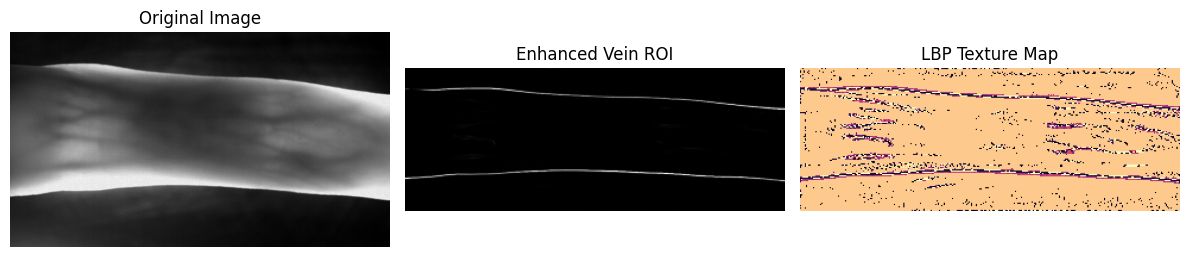


Step 3: Training handcrafted feature classifiers...

=== LBP Features ===
--- Logistic Regression ---
Classification Accuracy: 25.00%
FAR - Inter class: 21.07%
FRR - Intra class: 21.67%
EER = (FAR + FRR) / 2: 21.37%
Accuracy (1 - EER): 78.63%
--- SVM ---
Classification Accuracy: 23.33%
FAR - Inter class: 32.88%
FRR - Intra class: 33.33%
EER = (FAR + FRR) / 2: 33.11%
Accuracy (1 - EER): 66.89%

=== HOG Features ===
--- Logistic Regression ---
Classification Accuracy: 88.33%
FAR - Inter class: 4.86%
FRR - Intra class: 5.00%
EER = (FAR + FRR) / 2: 4.93%
Accuracy (1 - EER): 95.07%
--- SVM ---
Classification Accuracy: 81.67%
FAR - Inter class: 7.97%
FRR - Intra class: 6.67%
EER = (FAR + FRR) / 2: 7.32%
Accuracy (1 - EER): 92.68%

=== LDP Features ===
--- Logistic Regression ---
Classification Accuracy: 20.00%
FAR - Inter class: 26.27%
FRR - Intra class: 25.00%
EER = (FAR + FRR) / 2: 25.64%
Accuracy (1 - EER): 74.36%
--- SVM ---
Classification Accuracy: 16.67%
FAR - Inter class: 27.85%
FRR 

,Model Type,Feature Method,Classifier,Classification Accuracy,FAR - Inter class,FRR - Intra class,EER = (FAR + FRR) / 2,Accuracy (1 - EER),EER Threshold
2,Handcrafted,HOG,Logistic Regression,0.883333,0.048588,0.050000,0.049294,0.950706,0.000605
3,Handcrafted,HOG,SVM,0.816667,0.079661,0.066667,0.073164,0.926836,0.022655
0,Handcrafted,LBP,Logistic Regression,0.250000,0.210734,0.216667,0.213701,0.786299,0.017387
1,Handcrafted,LBP,SVM,0.233333,0.328814,0.333333,0.331073,0.668927,0.018740
4,Handcrafted,LDP,Logistic Regression,0.200000,0.262712,0.250000,0.256356,0.743644,0.000948
5,Handcrafted,LDP,SVM,0.166667,0.278531,0.283333,0.280932,0.719068,0.017899



Best result by classification accuracy:
HOG + Logistic Regression: 88.33%


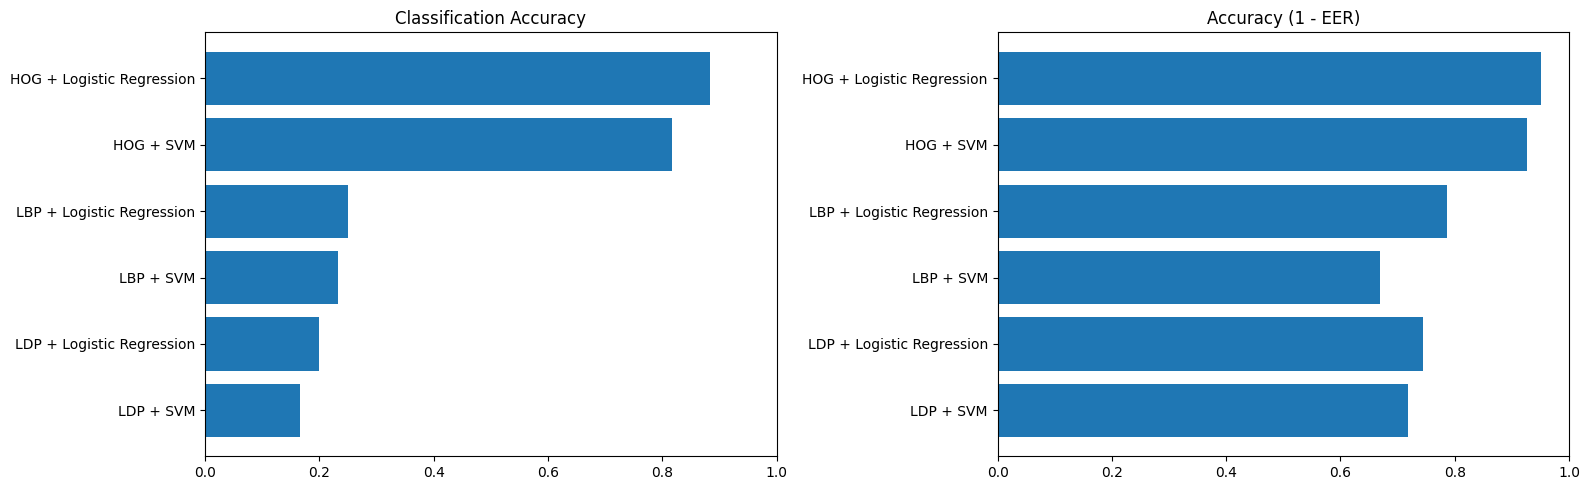

In [ ]:
def _predict_proba_matrix(clf, X_test):
    probs_raw = clf.predict_proba(X_test)
    if isinstance(probs_raw, list):
        return np.array([p[:, 1] for p in probs_raw]).T
    return probs_raw


def _far_frr_eer_from_scores(y_test, probs):
    far_values, tpr_values, thresholds = roc_curve(y_test.ravel(), probs.ravel())
    frr_values = 1 - tpr_values

    best_idx = np.argmin(np.abs(far_values - frr_values))
    far_inter_class = far_values[best_idx]
    frr_intra_class = frr_values[best_idx]
    eer = (far_inter_class + frr_intra_class) / 2

    return far_inter_class, frr_intra_class, eer, thresholds[best_idx]


def build_feature_sets(df_paths, use_preprocess_v2=True):
    feature_sets = {
        "LBP": [],
        "HOG": [],
        "LDP": [],
    }
    targets = []
    preview_payload = None

    print(f"Step 2: Processing {len(df_paths)} images...")
    for i, (idx, path) in enumerate(df_paths.items()):
        raw_img = imread(path, as_gray=True)

        if use_preprocess_v2:
            roi = fv_preprocess_v2(raw_img)
            seg = enhanced = None
        else:
            roi, seg, enhanced = fv_preprocess(raw_img)

        lbp_feat, lbp_img = extract_lbp_features(roi)
        hog_feat = extract_hog_features(roi)
        ldp_feat, ldp_img = extract_ldp_features(roi)

        feature_sets["LBP"].append(lbp_feat)
        feature_sets["HOG"].append(hog_feat)
        feature_sets["LDP"].append(ldp_feat)


        targets.append(idx[0])

        if i == 0:
            preview_payload = (raw_img, seg, enhanced, roi, lbp_img)

    return feature_sets, np.array(targets), preview_payload


def compare_handcrafted_features(feature_sets, y):
    lb = LabelBinarizer()
    y_bin = lb.fit_transform(y)

    classifiers = {
        "Logistic Regression": lambda: make_pipeline(
            StandardScaler(),
            OneVsRestClassifier(LogisticRegression(max_iter=5000, C=5.0))
        ),
        "SVM": lambda: make_pipeline(
            StandardScaler(),
            OneVsRestClassifier(SVC(C=100, gamma="scale", kernel="rbf", probability=True, random_state=42))
        ),
    }

    results = []
    for method_name, features in feature_sets.items():
        X = np.array(features)
        X_train, X_test, y_train, y_test, labels_train, labels_test = train_test_split(
            X, y_bin, y, test_size=0.25, stratify=y, random_state=42
        )

        print(f"\n=== {method_name} Features ===")
        for clf_name, build_clf in classifiers.items():
            clf = build_clf()
            clf.fit(X_train, y_train)
            probs = _predict_proba_matrix(clf, X_test)
            predicted_labels = lb.classes_[np.argmax(probs, axis=1)]

            far_inter_class, frr_intra_class, eer, threshold = _far_frr_eer_from_scores(y_test, probs)
            classification_accuracy = accuracy_score(labels_test, predicted_labels)

            results.append({
                "Model Type": "Handcrafted",
                "Feature Method": method_name,
                "Classifier": clf_name,
                "Classification Accuracy": classification_accuracy,
                "FAR - Inter class": far_inter_class,
                "FRR - Intra class": frr_intra_class,
                "EER = (FAR + FRR) / 2": eer,
                "Accuracy (1 - EER)": 1 - eer,
                "EER Threshold": threshold,
            })

            print(f"--- {clf_name} ---")
            print(f"Classification Accuracy: {classification_accuracy:.2%}")
            print(f"FAR - Inter class: {far_inter_class:.2%}")
            print(f"FRR - Intra class: {frr_intra_class:.2%}")
            print(f"EER = (FAR + FRR) / 2: {eer:.2%}")
            print(f"Accuracy (1 - EER): {1 - eer:.2%}")

    return pd.DataFrame(results)


def main():
    print("Step 1: Loading Dataset...")
    try:
        df_paths = get_image_path("li")
        if len(df_paths) == 0:
            raise ValueError("No images found. Please check DATASET_PATH and finger_type.")

        feature_sets, y, preview_payload = build_feature_sets(df_paths, use_preprocess_v2=True)

        if preview_payload is not None:
            raw_img, seg, enhanced, roi, lbp_img = preview_payload
            if seg is None:
                plt.figure(figsize=(12, 4))
                for ax, img, title, cmap in [
                    (plt.subplot(1, 3, 1), raw_img, "Original Image", "gray"),
                    (plt.subplot(1, 3, 2), roi, "Enhanced Vein ROI", "gray"),
                    (plt.subplot(1, 3, 3), lbp_img, "LBP Texture Map", "magma"),
                ]:
                    ax.imshow(img, cmap=cmap)
                    ax.set_title(title)
                    ax.axis("off")
                plt.tight_layout()
                plt.savefig("FYP_Results.png")
                plt.show()
            else:
                save_report_figures(raw_img, seg, enhanced, roi, lbp_img)

        print("\nStep 3: Training handcrafted feature classifiers...")
        results_df = compare_handcrafted_features(feature_sets, y)

        display(results_df.sort_values("Classification Accuracy", ascending=False))

        print("\nBest result by classification accuracy:")
        best_row = results_df.loc[results_df["Classification Accuracy"].idxmax()]
        print(
            f"{best_row['Feature Method']} + {best_row['Classifier']}: "
            f"{best_row['Classification Accuracy']:.2%}"
        )

        plot_results(results_df)
        return results_df

    except Exception as e:
        print(f"An error occurred: {e}")


def plot_results(results_df):
    plot_df = results_df.copy()
    plot_df["Method"] = plot_df["Feature Method"] + " + " + plot_df["Classifier"]
    plot_df = plot_df.sort_values("Classification Accuracy", ascending=True)

    fig, axes = plt.subplots(1, 2, figsize=(16, max(5, len(plot_df) * 0.35)))
    axes[0].barh(plot_df["Method"], plot_df["Classification Accuracy"])
    axes[0].set_title("Classification Accuracy")
    axes[0].set_xlim(0, 1)

    axes[1].barh(plot_df["Method"], plot_df["Accuracy (1 - EER)"])
    axes[1].set_title("Accuracy (1 - EER)")
    axes[1].set_xlim(0, 1)

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    main()